In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

In [2]:
#Setting constants
TEST_SPLIT = 0.2
TEXT_DATA = 'https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv'

In [3]:
#Accuracy calculation function
from sklearn.metrics import accuracy_score
def evaluate_model(predict_fun, X_train, y_train, X_test, y_test):
    #Training prediction
   y_predict_train = predict_fun(X_train)
   train_acc = accuracy_score(y_train,y_predict_train)
    #Test prediction
   y_predict_test = predict_fun(X_test)
   test_acc = accuracy_score(y_test,y_predict_test)
    
   return train_acc, test_acc

In [4]:
#Calculating confidence Interval
from math import sqrt
def error_conf(error, n):
   term = 1.96*sqrt((error*(1-error))/n)
   lb = error - term
   ub = error + term
    
   return lb, ub

In [5]:
#Loading the dataset
df = pd.read_csv(TEXT_DATA)

In [6]:
#Checking dataset
print(df.shape)
print(df.head())

(6335, 4)
      id                                              title  \
0   8476                       You Can Smell Hillary’s Fear   
1  10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2   3608        Kerry to go to Paris in gesture of sympathy   
3  10142  Bernie supporters on Twitter erupt in anger ag...   
4    875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [7]:
#Dropping unnecessary columns
df.drop(labels=['id','title'], axis='columns', inplace=True)

In [8]:
# Removing empty text rows, only select stories with lengths gt 0 -- there are some texts with len = 0
mask = list(df['text'].apply(lambda x: len(x) > 0))
df = df[mask]

In [9]:
#Separating features and labels
texts = df['text']
labels = df['label']

In [10]:
#Count total texts
print('Found %s texts.' %texts.shape[0])

Found 6335 texts.


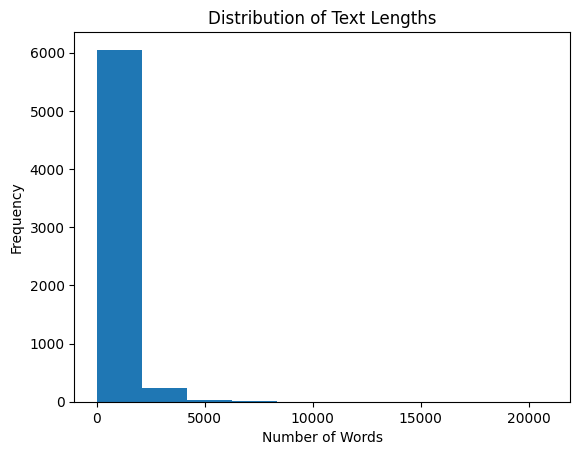

<Figure size 640x480 with 0 Axes>

In [34]:
#Text length visualization
text_lengths = texts.apply(lambda x: len(x.split(" ")))
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.hist(text_lengths)
plt.show()
plt.savefig("histogram.png")

In [12]:
# Convert text into numbers 
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(analyzer = "word", 
 binary = True, 
 min_df = 2,
 stop_words='english')

In [13]:
#Create document-term matrix
docarray = vectorizer.fit_transform(texts).toarray()
docterm = pd.DataFrame(docarray, columns=vectorizer.get_feature_names_out())

In [14]:
#Train-Test Split
from sklearn.model_selection import train_test_split
docterm_train, docterm_test, y_train, y_test = train_test_split(docterm, labels, test_size=TEST_SPLIT,random_state=42)

In [15]:
#Train Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(docterm_train, y_train)

MultinomialNB()

In [16]:
#Evaluate Model
train_acc, test_acc = evaluate_model(model.predict, docterm_train, y_train, docterm_test, y_test)
print("Training Accuracy: {:.2f}%".format(train_acc*100))
print("Testing Accuracy: {:.2f}%".format(test_acc*100))

Training Accuracy: 94.83%
Testing Accuracy: 89.74%


In [17]:
#Calculates Confidence Interval
n = docterm_test.shape[0]
lb, ub = error_conf(1-test_acc, n)

print("95% confidence interval: {:.2f}%-{:.2f}%".format((1-ub)*100,
(1-lb)*100))

95% confidence interval: 88.07%-91.41%


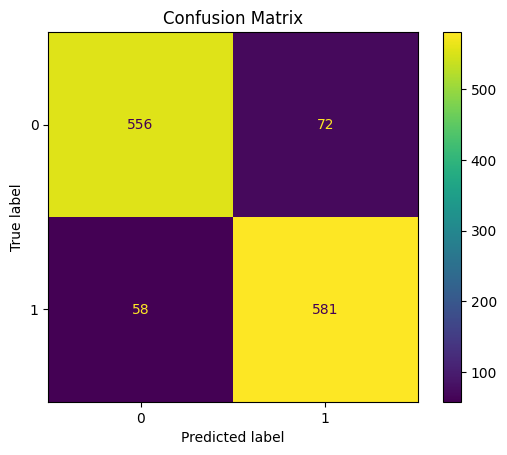

<Figure size 640x480 with 0 Axes>

In [33]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(docterm_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")
plt.show()
plt.savefig("ConfusionMatrix.png")

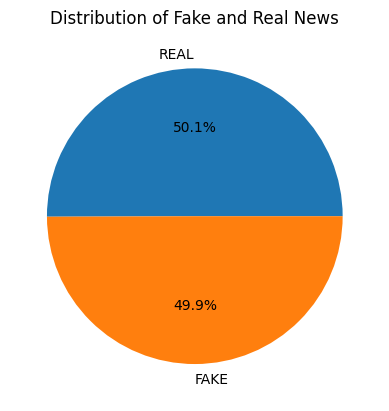

<Figure size 640x480 with 0 Axes>

In [32]:
#Fake vs Real Count Graph
labels.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Distribution of Fake and Real News")
plt.ylabel("")

plt.show()
plt.savefig("ValueCount.png")

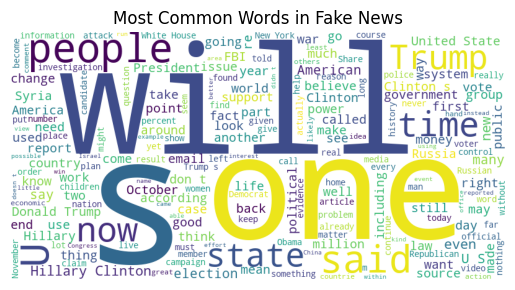

<Figure size 640x480 with 0 Axes>

In [35]:
#Word Cloud
from wordcloud import WordCloud

fake_text = " ".join(df[df['label']=='FAKE']['text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Common Words in Fake News")
plt.show()
plt.savefig("WordCloud.png")